## **1. Data Load & Overview**

In [1]:
# 1.1 Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../1_data/Airline_review_rawdata.csv")
print("Data loaded successfully!")

Data loaded successfully!


In [2]:
# 1.2 Shape & Data Types
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

=== Shape ===
(23171, 20)

=== Data Types ===
Unnamed: 0                  int64
Airline Name               object
Overall_Rating             object
Review_Title               object
Review Date                object
Verified                     bool
Review                     object
Aircraft                   object
Type Of Traveller          object
Seat Type                  object
Route                      object
Date Flown                 object
Seat Comfort              float64
Cabin Staff Service       float64
Food & Beverages          float64
Ground Service            float64
Inflight Entertainment    float64
Wifi & Connectivity       float64
Value For Money           float64
Recommended                object
dtype: object


In [3]:
# 1.3 Data Structure
df.head()

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [4]:
# 1.4 Missing Values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df.sort_values('missing_%', ascending=False)

,missing_count,missing_%
Wifi & Connectivity,17251,74.5
Aircraft,16042,69.2
Inflight Entertainment,12342,53.3
Food & Beverages,8671,37.4
Ground Service,4793,20.7
Cabin Staff Service,4260,18.4
Seat Comfort,4155,17.9
Route,3828,16.5
Date Flown,3754,16.2
Type Of Traveller,3738,16.1


> ### **Skytrax Review Data Characteristics**
> 
> The table below summarizes the input fields collected from the Skytrax airline review submission form and their characteristics. **This explains the reason that there are substantial missing values in certain columns.**
> 
> For reference, see the original review form: [Skytrax Review Form](https://www.airlinequality.com/write-a-review/?type=airline)

| Column | Scale | Notes |
|---|---|---|
| Airline Name | - | 497 unique airlines |
| Review_Title | - | Supplementary for analysis |
| Review Date | - | Scraping date, not flight date |
| Verified | True/False | Whether e-ticket or boarding pass was submitted |
| Review | 150~3500 chars | **Primary column for text analysis** |
| Aircraft | - | Optional field; high missingness |
| Type Of Traveller | - | Business / Family / Couple / Solo |
| Seat Type | - | First / Business / Premium Economy / Economy |
| Route | - | Free-text input |
| Date Flown | - | Actual flight date |
| Seat Comfort | 1~5 | Required field |
| Cabin Staff Service | 1~5 | Required field |
| Food & Beverages | 1~5 + N/A | N/A = service not available |
| Ground Service | 1~5 | Required field |
| Inflight Entertainment | 1~5 + N/A | N/A = service not available |
| Wifi & Connectivity | 1~5 + N/A | N/A = service not available |
| Value For Money | 1~5 | Required field |
| Overall_Rating | 1~10 | Different scale from sub-ratings |
| Recommended | Yes/No | **Target variable** |

## **2. Initial Exploratory Data Analysis (EDA)**

In [5]:
# 2.1 Target Variable (Recommended)
print(df['Recommended'].value_counts())
print(df['Recommended'].value_counts(normalize=True).round(3) * 100)

Recommended
no     15364
yes     7807
Name: count, dtype: int64
Recommended
no     66.3
yes    33.7
Name: proportion, dtype: float64


In [6]:
# 2.2 Known Categorical Columns

print("=== Verified ===")
print(df['Verified'].value_counts())

print("\n=== Seat Type ===")
print(df['Seat Type'].value_counts(dropna=False))

print("\n=== Type Of Traveller ===")
print(df['Type Of Traveller'].value_counts(dropna=False))

=== Verified ===
Verified
True     12322
False    10849
Name: count, dtype: int64

=== Seat Type ===
Seat Type
Economy Class      19145
Business Class      2098
NaN                 1096
Premium Economy      646
First Class          186
Name: count, dtype: int64

=== Type Of Traveller ===
Type Of Traveller
Solo Leisure      7120
Couple Leisure    5265
Family Leisure    4352
NaN               3738
Business          2696
Name: count, dtype: int64


In [7]:
# 2.3 Columns Requiring Investigation
# Overall Rating
df["Overall_Rating"].value_counts(dropna=False)

Overall_Rating
1    11595
2     2296
9     1768
8     1757
3     1356
7     1193
4      859
n      842
5      830
6      675
Name: count, dtype: int64

> ### **Why Dropping `Overall_Rating` is needed?**
> 
> - **Missing 10**: Skytrax reviews use a 1 to 10 scale for `Overall_Rating`. The absence of 10-point ratings is unexplained and cannot be verified from the raw data alone.
> 
> - **Ambiguous 'n' values**: 842 entries contain 'n' which likely represents None or N/A, but cannot be reliably imputed or removed without introducing bias.
> 
> - **Data Leakage Risk**: `Overall_Rating` is logically correlated with the target variable `Recommended` (e.g., low ratings likely map to "no", high ratings to "yes"), which would inflate model performance and obscure the true predictive power of text-based sentiment features.

In [8]:
# Review Date (by Year)
df['Review Date'] = pd.to_datetime(df['Review Date'], format='mixed', errors='coerce')
df['Review Date'].dt.year.value_counts().sort_index()

Review Date
2002      14
2003      45
2004     101
2005     136
2006     141
2007     168
2008     281
2009     287
2010     332
2011     461
2012     403
2013     494
2014     593
2015    1070
2016    1210
2017    1148
2018    1675
2019    2869
2020    1483
2021    1016
2022    3826
2023    5418
Name: count, dtype: int64

In [9]:
# Date Flown (by Year)
df['Date Flown'] = pd.to_datetime(df['Date Flown'], format='%B %Y', errors='coerce')
df['Date Flown'].dt.year.value_counts().sort_index()

Date Flown
2012.0       1
2014.0      12
2015.0     891
2016.0    1155
2017.0    1160
2018.0    1774
2019.0    2929
2020.0    1378
2021.0    1022
2022.0    4115
2023.0    4980
Name: count, dtype: int64

In [10]:
# Airline Name
print(f"Total unique airlines: {df['Airline Name'].nunique()}")
df['Airline Name'].value_counts().head(10)

Total unique airlines: 497


Airline Name
Caribbean Airlines     100
GoAir                  100
Germanwings            100
Philippine Airlines    100
Bangkok Airways        100
Garuda Indonesia       100
Batik Air              100
Swoop                  100
Frontier Airlines      100
Sunwing Airlines       100
Name: count, dtype: int64

In [11]:
# Aircraft
print(f"Total unique aircraft: {df['Aircraft'].nunique()}")
df['Aircraft'].value_counts().head(10)

Total unique aircraft: 1048


Aircraft
A320              1041
Boeing 737-800     553
Boeing 737         404
A330               349
Boeing 787         349
A321               271
A319               233
Boeing 787-9       174
Boeing 777         160
A330-300           142
Name: count, dtype: int64

In [12]:
# Route
print(f"Total unique routes: {df['Route'].nunique()}")
df['Route'].value_counts().head(10)

Total unique routes: 13607


Route
Melbourne to Sydney          43
Sydney to Melbourne          35
Cape Town to Johannesburg    34
Cusco to Lima                30
Bangkok to Phuket            28
Kuala Lumpur to Singapore    27
Johannesburg to Cape Town    27
Bangkok to Chiang Mai        26
Johannesburg to Durban       22
Toronto to Calgary           21
Name: count, dtype: int64

In [13]:
# 2.4 Numerical Rating Columns
rating_cols = ['Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
               'Ground Service', 'Inflight Entertainment',
               'Wifi & Connectivity', 'Value For Money']

df[rating_cols].describe()

,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money
count,19016.000000,18911.000000,14500.000000,18378.000000,10829.000000,5920.000000,22105.000000
mean,2.618374,2.871609,2.553586,2.353738,2.179056,1.780405,2.451165
std,1.464840,1.604631,1.526314,1.595747,1.488839,1.318800,1.594155
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,3.000000,3.000000,2.000000,1.000000,2.000000,1.000000,2.000000
75%,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


> ### **Further Investigation Needed**
>
> - **Reguired Columns (Scale 1 to 5)** → **Both** missing values and 0 are **NOT** accepted.  
> `Seat Comfort`, `Cabin Staff Service`, `Ground Service`, `Value For Money`
>
> - **Non-required Column (N/A or Scale 1 to 5)** → Missing values are accepted, but 0 is **NOT** accepted.  
> `Food & Beverages`, `Inflight Entertainment`, `Wifi & Connectivity`

In [14]:
# 2.5 Further Investigation (Except for "Ground Service" as its min value is 1)

rating_cols = ['Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
               'Ground Service', 'Inflight Entertainment',
               'Wifi & Connectivity', 'Value For Money']

results = []
for col in rating_cols:
    missing = df[col].isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    zero_count = (df[col] == 0.0).sum()
    zero_pct = (zero_count / len(df) * 100).round(2)
    results.append({'column': col, 'missing_count': missing, 'missing_%': missing_pct, 
                    'zero_count': zero_count, 'zero_%': zero_pct})

invalid_df = pd.DataFrame(results)
invalid_df

,column,missing_count,missing_%,zero_count,zero_%
0,Seat Comfort,4155,17.93,144,0.62
1,Cabin Staff Service,4260,18.39,130,0.56
2,Food & Beverages,8671,37.42,252,1.09
3,Ground Service,4793,20.69,0,0.00
4,Inflight Entertainment,12342,53.26,521,2.25
5,Wifi & Connectivity,17251,74.45,1,0.00
6,Value For Money,1066,4.60,137,0.59


> ### **Invalid Value Handling**
> As shown in the table above, the proportion of 0 values across all numerical rating columns is very small (0.00% – 2.25%). Since 0 is not a valid rating on the Skytrax scale (1–5), these values are **replaced with NaN** to avoid data  distortion. The impact on the dataset is minimal given the low proportion.
>
> Additionally, missing value imputation is intentionally deferred to the modelling stage. These numerical columns are only relevant for Set A, which relies on structured sub-ratings as features. Sets B, C, D, and E are entirely text-based and do not use these columns. **Applying imputation here (prior to train/test split) would risk data leakage**, as imputation statistics would be computed on the full dataset rather than the training set alone. Therefore, **all imputation, scaling, and encoding steps will be handled within the modelling pipeline after the split.**

## **3. Data Cleaning**

In [15]:
# 3.1 Deleting Unnecessary Columns
df = df.drop(columns=["Unnamed: 0", "Overall_Rating", "Aircraft", "Route", "Review Date"])
df.head(5)

,Airline Name,Review_Title,Verified,Review,Type Of Traveller,Seat Type,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,AB Aviation,"""pretty decent airline""",True,Moroni to Moheli. Turned out to be a pretty ...,Solo Leisure,Economy Class,2019-11-01,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,AB Aviation,"""Not a good airline""",True,Moroni to Anjouan. It is a very small airline...,Solo Leisure,Economy Class,2019-06-01,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,AB Aviation,"""flight was fortunately short""",True,Anjouan to Dzaoudzi. A very small airline an...,Solo Leisure,Economy Class,2019-06-01,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,Adria Airways,"""I will never fly again with Adria""",False,Please do a favor yourself and do not fly wi...,Solo Leisure,Economy Class,2019-09-01,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,Adria Airways,"""it ruined our last days of holidays""",True,Do not book a flight with this airline! My fr...,Couple Leisure,Economy Class,2019-09-01,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [16]:
# 3.2 Replace 0 with NaN in Rating Columns

rating_cols = ['Seat Comfort', 'Cabin Staff Service', 'Food & Beverages',
               'Ground Service', 'Inflight Entertainment',
               'Wifi & Connectivity', 'Value For Money']

# Check before
print("=== Before: Zero Count ===")
for col in rating_cols:
    print(f"{col}: {(df[col] == 0).sum()} zeros")

# Replace 0 with NaN
df[rating_cols] = df[rating_cols].replace(0, float('nan'))

# Check after
print("\n=== After: Zero Count ===")
for col in rating_cols:
    print(f"{col}: {(df[col] == 0).sum()} zeros")

=== Before: Zero Count ===
Seat Comfort: 144 zeros
Cabin Staff Service: 130 zeros
Food & Beverages: 252 zeros
Ground Service: 0 zeros
Inflight Entertainment: 521 zeros
Wifi & Connectivity: 1 zeros
Value For Money: 137 zeros

=== After: Zero Count ===
Seat Comfort: 0 zeros
Cabin Staff Service: 0 zeros
Food & Beverages: 0 zeros
Ground Service: 0 zeros
Inflight Entertainment: 0 zeros
Wifi & Connectivity: 0 zeros
Value For Money: 0 zeros


In [17]:
# 3.3 Handle Missing Values in Categorical Columns

# Type Of Traveller: missing → 'Unknown' (to be used in Encoding later)
df['Type Of Traveller'] = df['Type Of Traveller'].fillna('Unknown')

# Seat Type: missing → 'Unknown' (to be used in Encoding later)
df['Seat Type'] = df['Seat Type'].fillna('Unknown')

# Verify
print("=== Type Of Traveller ===")
print(df['Type Of Traveller'].value_counts(dropna=False))
print("\n=== Seat Type ===")
print(df['Seat Type'].value_counts(dropna=False))

=== Type Of Traveller ===
Type Of Traveller
Solo Leisure      7120
Couple Leisure    5265
Family Leisure    4352
Unknown           3738
Business          2696
Name: count, dtype: int64

=== Seat Type ===
Seat Type
Economy Class      19145
Business Class      2098
Unknown             1096
Premium Economy      646
First Class          186
Name: count, dtype: int64


In [18]:
# 3.4 Feature Creation & Change

# Recommended: yes → 1, no → 0
df['Recommended'] = df['Recommended'].map({'yes': 1, 'no': 0})

# Covid Feature Creation: missing → covid_period = 0 (cannot determine, treated as non-COVID)
df['Date Flown'] = pd.to_datetime(df['Date Flown'], format='%B %Y', errors='coerce')
df['Covid_Period'] = df['Date Flown'].dt.year.isin([2020, 2021, 2022]).astype(int)
df = df.drop(columns=['Date Flown'])

# Review Length Creation
df['review_length'] = df['Review'].str.len()

## **4. Further Exploratory Data Analysis (EDA)**

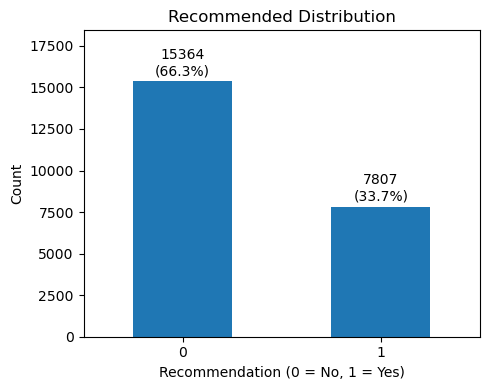

In [19]:
# 4.1 Recommended Distribution (Target Variable)

import matplotlib.pyplot as plt
import seaborn as sns

ax = df['Recommended'].value_counts().sort_index().plot(kind='bar', figsize=(5, 4))

for p in ax.patches:
    ax.annotate(f"{p.get_height()}\n({p.get_height()/len(df)*100:.1f}%)", 
                (p.get_x() + p.get_width()/2, p.get_height() + 200), 
                ha='center', va='bottom')

plt.title('Recommended Distribution')
plt.xlabel('Recommendation (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.ylim(0, max(df['Recommended'].value_counts()) * 1.2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

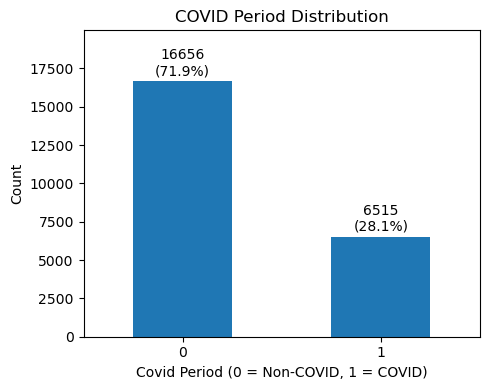

In [20]:
# 4.2 COVID Period Distribution

ax2 = df['Covid_Period'].value_counts().sort_index().plot(kind='bar', figsize=(5, 4))

for p in ax2.patches:
    ax2.annotate(f"{p.get_height()}\n({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width()/2, p.get_height() + 200),
                ha='center', va='bottom')

plt.title('COVID Period Distribution')
plt.xlabel('Covid Period (0 = Non-COVID, 1 = COVID)')
plt.ylabel('Count')
plt.ylim(0, max(df['Covid_Period'].value_counts()) * 1.2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

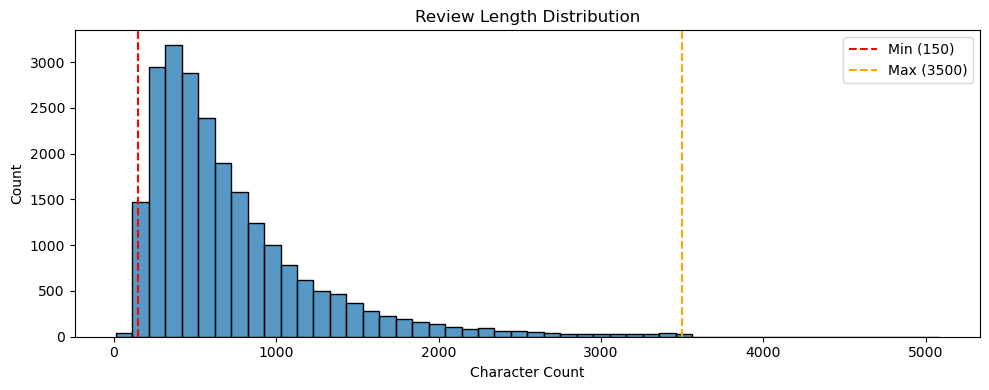

Mean review length: 722 chars
Median review length: 561 chars
Reviews under 150 chars: 191
Reviews over 3500 chars: 10


In [21]:
# 4.3 Review Length Distribution

plt.figure(figsize=(10, 4))
sns.histplot(df['review_length'], bins=50)
plt.title('Review Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Count')
plt.axvline(x=150, color='red', linestyle='--', label='Min (150)')
plt.axvline(x=3500, color='orange', linestyle='--', label='Max (3500)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean review length: {df['review_length'].mean():.0f} chars")
print(f"Median review length: {df['review_length'].median():.0f} chars")
print(f"Reviews under 150 chars: {(df['review_length'] < 150).sum()}")
print(f"Reviews over 3500 chars: {(df['review_length'] > 3500).sum()}")

> ### **Key Insights from Review Length Distribution**
>
> - **Sufficient Review Length**: With a mean of 722 characters and a median of 561 characters, the majority of reviews contain enough text for meaningful sentiment analysis.
>
> - **Short Review Removal**: 191 reviews (0.8%) fall below Skytrax's minimum review length policy of 150 characters. Given the negligible proportion, these reviews will be removed to reduce noise in aspect-level sentiment analysis, where insufficient text may result in few or no aspect keywords being detected.

In [22]:
# 4.4 Remove reviews under 150 chars

df = df[df['review_length'] >= 150]
print(f"Removed {191} short reviews → {df.shape[0]} rows remaining")

Removed 191 short reviews → 22980 rows remaining


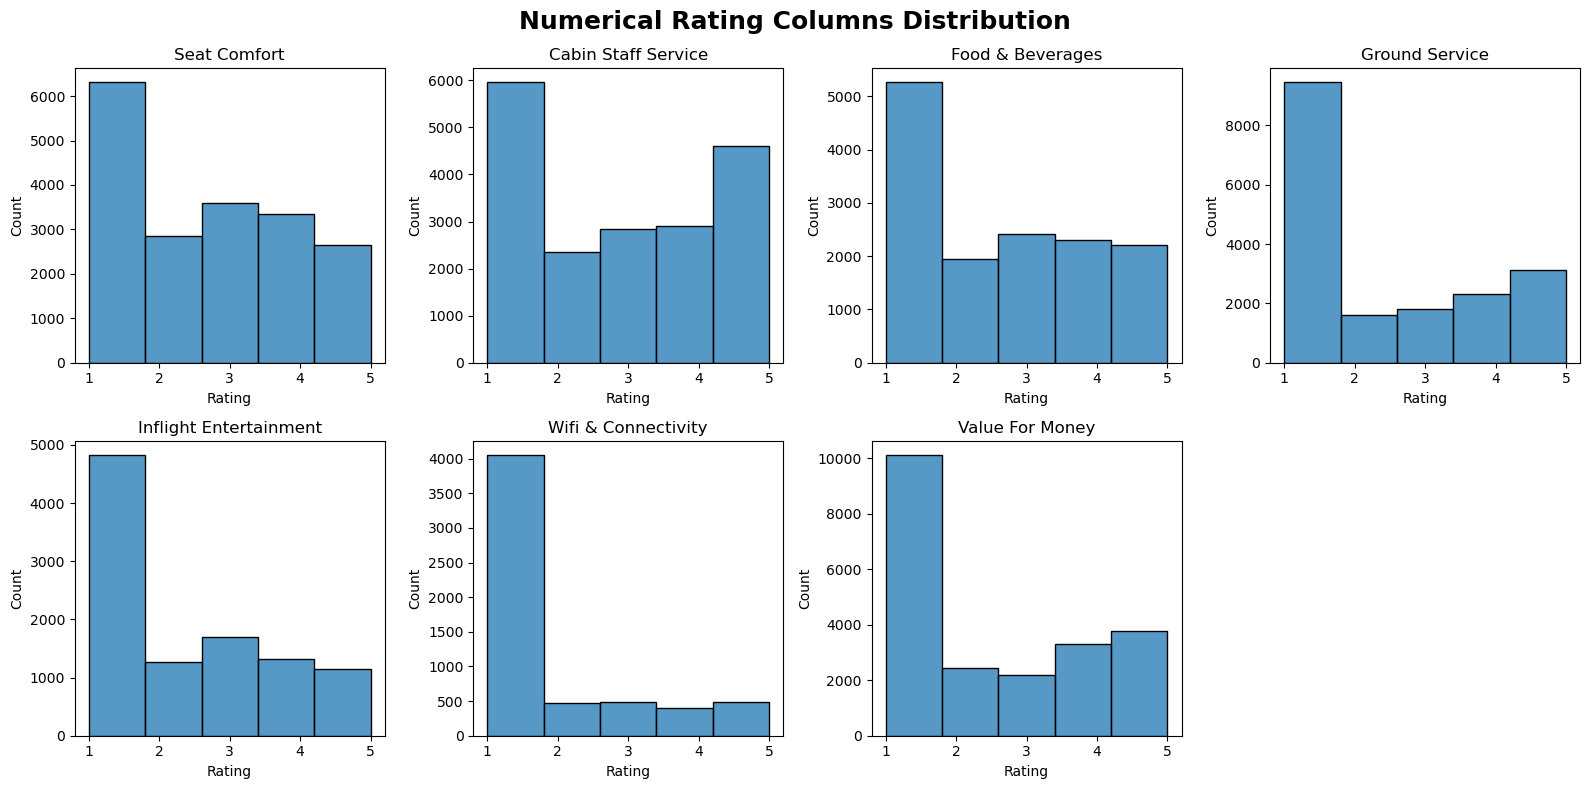

In [23]:
# 4.5 Numerical Rating Columns Distribution

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(rating_cols):
    sns.histplot(df[col].dropna(), bins=5, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Rating')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Numerical Rating Columns Distribution', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

> ### **Key Insights from Numerical Rating Distribution**
>
> - **`Overall Negative Bias`**: The majority of rating columns show 1 as the most frequent score, reflecting a tendency for dissatisfied passengers to leave reviews more often. This is consistent with the Recommended distribution where 66.3% responded "No".
>
> - **`Seat Comfort & Cabin Staff Service`**: Both show a bimodal distribution with peaks at 1 and 5, suggesting that passengers who had extreme experiences (very good or very bad) are most likely to leave a review.
>
> - **`Ground Service`**: Heavily skewed toward 1, indicating the highest level of dissatisfaction among all service dimensions.
>
> - **`Wifi & Connectivity`**: Overwhelmingly rated 1, reflecting consistently low satisfaction with in-flight wifi across airlines.

## **5. Save Cleaned Dataset**

In [24]:
import os
os.makedirs('../1_data/01_processed', exist_ok=True)
out_path = '../1_data/01_processed/01_cleaned.csv'
df.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
print("\n")
print(f"Final shape: {df.shape}")
df.info()

Saved → ../1_data/01_processed/01_cleaned.csv


Final shape: (22980, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 22980 entries, 0 to 23170
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Airline Name            22980 non-null  object 
 1   Review_Title            22980 non-null  object 
 2   Verified                22980 non-null  bool   
 3   Review                  22980 non-null  object 
 4   Type Of Traveller       22980 non-null  object 
 5   Seat Type               22980 non-null  object 
 6   Seat Comfort            18763 non-null  float64
 7   Cabin Staff Service     18673 non-null  float64
 8   Food & Beverages        14162 non-null  float64
 9   Ground Service          18292 non-null  float64
 10  Inflight Entertainment  10245 non-null  float64
 11  Wifi & Connectivity     5896 non-null   float64
 12  Value For Money         21806 non-null  float64
 13  Recommended            